<a href="https://colab.research.google.com/github/Zaki2409/AI-Engineer-Hands-on/blob/master/ANN_with_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt


In [2]:
torch.manual_seed(42)

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"using device : {device}")

using device : cuda


In [4]:
df = pd.read_csv('fashion-mnist_test.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,9,8,...,103,87,56,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0,...,34,0,0,0,0,0,0,0,0,0
2,2,0,0,0,0,0,0,14,53,99,...,0,0,0,0,63,53,31,0,0,0
3,2,0,0,0,0,0,0,0,0,0,...,137,126,140,0,133,224,222,56,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df1 = pd.read_csv('fashion-mnist_train.csv')
df1.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df.shape


(10000, 785)

In [7]:
df1.shape

(60000, 785)

Text(0.5, 0.98, '4 X 4 Grid of Images')

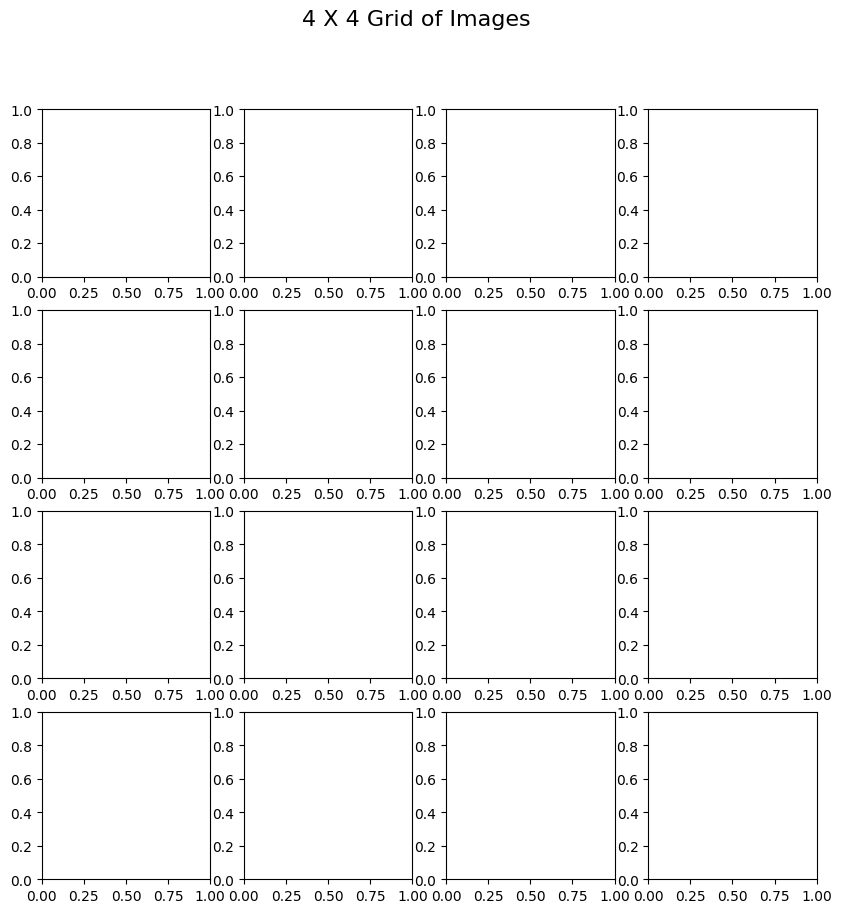

In [8]:
#create a 4 X4 grid
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('4 X 4 Grid of Images', fontsize=16)

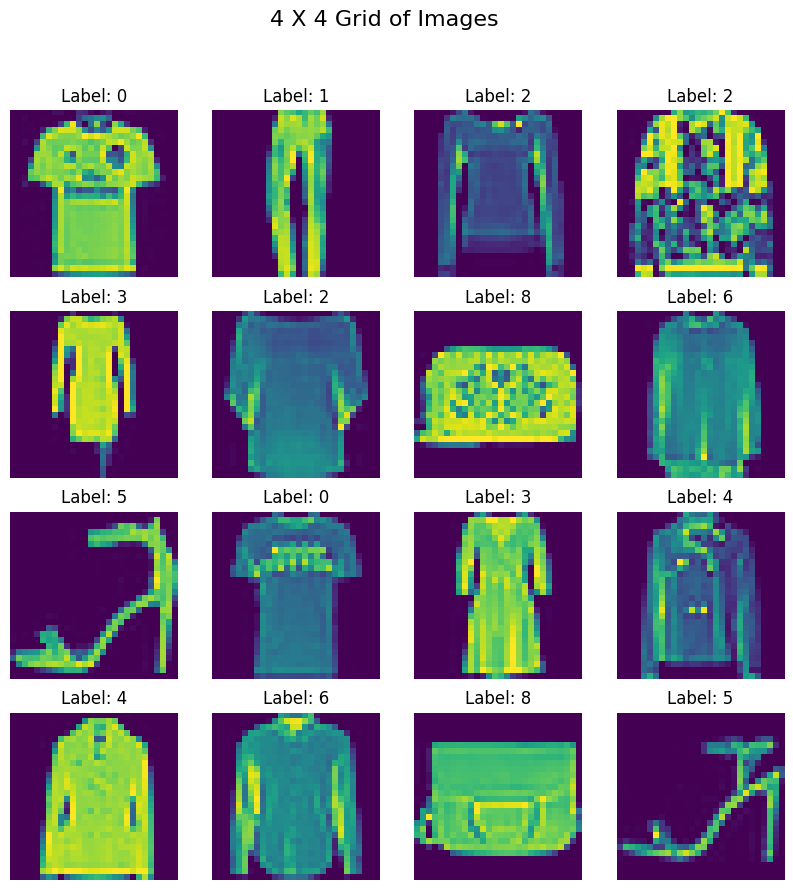

In [9]:
#create a 4 X4 grid
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('4 X 4 Grid of Images', fontsize=16)

#plot the first 16 imahes from the dataset

for i, ax in enumerate(axes.flat):
  img =df.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(f'Label: {df.iloc[i,0]}')
plt.show()

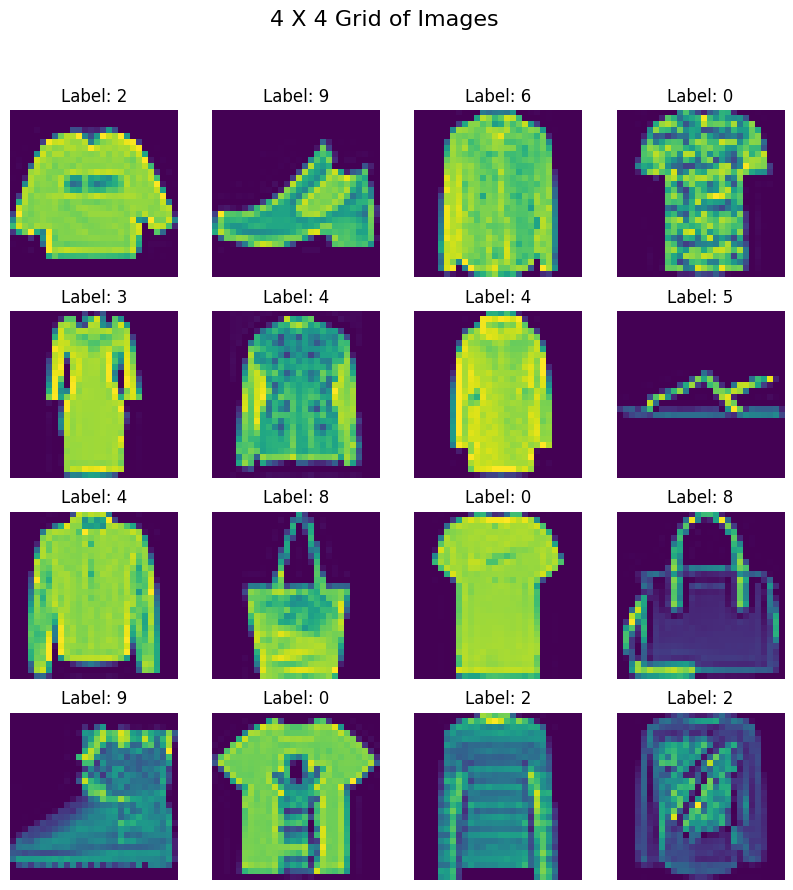

In [10]:
#create a 4 X4 grid
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle('4 X 4 Grid of Images', fontsize=16)

#plot the first 16 imahes from the dataset

for i, ax in enumerate(axes.flat):
  img =df1.iloc[i,1:].values.reshape(28,28)
  ax.imshow(img)
  ax.axis('off')
  ax.set_title(f'Label: {df1.iloc[i,0]}')
plt.show()

In [11]:
#train test split
X =df.iloc[:,1:].values
y = df.iloc[:,0].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [12]:
#train test split
X1 =df1.iloc[:,1:].values
y1 = df1.iloc[:,0].values
X_train1, X_test1, y_train1, y_test1 = train_test_split(X1, y1, test_size=0.2, random_state=42)


In [13]:
X_train

array([[  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ..., 115,  35,   0],
       [  0,   0,   0, ...,   0,   0,   0]])

In [14]:
X_test

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [15]:
y_test

array([4, 9, 6, ..., 5, 5, 1])

In [16]:
y_train

array([8, 5, 4, ..., 2, 9, 7])

In [17]:
#scaling
X_train = X_train/255.0
X_test = X_test/255.0

In [18]:
#scaling
X_train1 = X_train1/255.0
X_test1 = X_test1/255.0

In [19]:
#create custome class
class CustomDataset(Dataset):
  def __init__(self, features, labels):
    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self,index):
    return self.features[index], self.labels[index]

In [20]:
#create train and test dataset obejct
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(X_test, y_test)

In [21]:
#create train and test dataset obejct
train_dataset1 = CustomDataset(X_train1, y_train1)
test_dataset1 = CustomDataset(X_test1, y_test1)

In [22]:
len(train_dataset)

8000

In [23]:
len(train_dataset1)

48000

In [24]:
len(test_dataset)

2000

In [25]:
len(test_dataset1)

12000

In [26]:
#create train and test laoder
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [27]:
#create train and test laoder
train_loader1 = DataLoader(train_dataset1, batch_size=32, shuffle=True, pin_memory=True) #page mem pinned mem in os
test_loader1 = DataLoader(test_dataset1, batch_size=32, shuffle=False,pin_memory=True)

In [28]:
#deinfe NN CLASS
class myNN(nn.Module):
  def __init__(self, num_features):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)
    )
  def forward(self,X):
    return self.model(X)


In [29]:
#deinfe NN CLASS
class myNNdropout(nn.Module):
  def __init__(self, num_features):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(64, 10)
    )
  def forward(self,X):
    return self.model(X)


In [30]:
#deinfe NN CLASS
class myNNdropoutandBatchNorm(nn.Module):
  def __init__(self, num_features):
    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(128, 64),
        nn.BatchNorm1d(64),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(64, 10)
    )
  def forward(self,X):
    return self.model(X)


In [31]:
#set lr and epoch
epochs = 100
learning_rate = 0.1


In [32]:
#instancitai model and loss func and optmizer
model = myNN(X_train.shape[1])
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [33]:
#instancitai model and loss func and optmizer
model1 = myNN(X_train1.shape[1])
model1 = model1.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [34]:
#instancitai model and loss func and optmizer
model2 = myNNdropout(X_train1.shape[1])
model2 = model2.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [37]:
#instancitai model and loss func and optmizer
model3 = myNNdropoutandBatchNorm(X_train1.shape[1])
model3 = model3.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [38]:
#instancitai model and loss func and optmizer
model4 = myNNdropoutandBatchNorm(X_train1.shape[1])
model4 = model4.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)

In [39]:
#TRAIN LOOP

for epoch in range(epochs):
  total_epoch_loss =0
  for batch_features, batch_labels in train_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    #forward
    predicton = model(batch_features)

    #calcualte loss
    loss = criterion(predicton, batch_labels)
    #backpass
    optimizer.zero_grad() # gradient clear
    loss.backward()# gradient calucatesd

    #upadte param with newly callcauted gradients
    optimizer.step()

    total_epoch_loss += loss.item()

  avg_loss = total_epoch_loss/len(train_loader)
  print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}')


Epoch [1/100], Loss: 1.1267
Epoch [2/100], Loss: 0.6484
Epoch [3/100], Loss: 0.5483
Epoch [4/100], Loss: 0.4955
Epoch [5/100], Loss: 0.4568
Epoch [6/100], Loss: 0.4274
Epoch [7/100], Loss: 0.4015
Epoch [8/100], Loss: 0.3898
Epoch [9/100], Loss: 0.3660
Epoch [10/100], Loss: 0.3532
Epoch [11/100], Loss: 0.3345
Epoch [12/100], Loss: 0.3299
Epoch [13/100], Loss: 0.3174
Epoch [14/100], Loss: 0.3049
Epoch [15/100], Loss: 0.2907
Epoch [16/100], Loss: 0.2806
Epoch [17/100], Loss: 0.2739
Epoch [18/100], Loss: 0.2594
Epoch [19/100], Loss: 0.2595
Epoch [20/100], Loss: 0.2489
Epoch [21/100], Loss: 0.2348
Epoch [22/100], Loss: 0.2396
Epoch [23/100], Loss: 0.2206
Epoch [24/100], Loss: 0.2213
Epoch [25/100], Loss: 0.2118
Epoch [26/100], Loss: 0.2133
Epoch [27/100], Loss: 0.1963
Epoch [28/100], Loss: 0.1907
Epoch [29/100], Loss: 0.1870
Epoch [30/100], Loss: 0.1789
Epoch [31/100], Loss: 0.1805
Epoch [32/100], Loss: 0.1763
Epoch [33/100], Loss: 0.1668
Epoch [34/100], Loss: 0.1713
Epoch [35/100], Loss: 0

In [40]:
#TRAIN LOOP

for epoch in range(epochs):
  total_epoch_loss =0
  for batch_features, batch_labels in train_loader1:

    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    #forward
    predicton = model1(batch_features)

    #calcualte loss
    loss = criterion(predicton, batch_labels)
    #backpass
    optimizer.zero_grad() # gradient clear
    loss.backward()# gradient calucatesd

    #upadte param with newly callcauted gradients
    optimizer.step()

    total_epoch_loss += loss.item()

  avg_loss = total_epoch_loss/len(train_loader1)
  print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}')


Epoch [1/100], Loss: 2.3059
Epoch [2/100], Loss: 2.3059
Epoch [3/100], Loss: 2.3059
Epoch [4/100], Loss: 2.3059
Epoch [5/100], Loss: 2.3059
Epoch [6/100], Loss: 2.3059
Epoch [7/100], Loss: 2.3059
Epoch [8/100], Loss: 2.3059
Epoch [9/100], Loss: 2.3059
Epoch [10/100], Loss: 2.3059
Epoch [11/100], Loss: 2.3059
Epoch [12/100], Loss: 2.3059
Epoch [13/100], Loss: 2.3059
Epoch [14/100], Loss: 2.3059
Epoch [15/100], Loss: 2.3059
Epoch [16/100], Loss: 2.3059
Epoch [17/100], Loss: 2.3059
Epoch [18/100], Loss: 2.3059
Epoch [19/100], Loss: 2.3059
Epoch [20/100], Loss: 2.3059
Epoch [21/100], Loss: 2.3059
Epoch [22/100], Loss: 2.3059
Epoch [23/100], Loss: 2.3059
Epoch [24/100], Loss: 2.3059
Epoch [25/100], Loss: 2.3059
Epoch [26/100], Loss: 2.3059
Epoch [27/100], Loss: 2.3059
Epoch [28/100], Loss: 2.3059
Epoch [29/100], Loss: 2.3059
Epoch [30/100], Loss: 2.3059
Epoch [31/100], Loss: 2.3059
Epoch [32/100], Loss: 2.3059
Epoch [33/100], Loss: 2.3059
Epoch [34/100], Loss: 2.3059
Epoch [35/100], Loss: 2

In [41]:
#TRAIN LOOP

for epoch in range(epochs):
  total_epoch_loss =0
  for batch_features, batch_labels in train_loader1:

    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    #forward
    predicton = model2(batch_features)

    #calcualte loss
    loss = criterion(predicton, batch_labels)
    #backpass
    optimizer.zero_grad() # gradient clear
    loss.backward()# gradient calucatesd

    #upadte param with newly callcauted gradients
    optimizer.step()

    total_epoch_loss += loss.item()

  avg_loss = total_epoch_loss/len(train_loader1)
  print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}')


Epoch [1/100], Loss: 2.3007
Epoch [2/100], Loss: 2.3006
Epoch [3/100], Loss: 2.3010
Epoch [4/100], Loss: 2.3008
Epoch [5/100], Loss: 2.3010
Epoch [6/100], Loss: 2.3012
Epoch [7/100], Loss: 2.3010
Epoch [8/100], Loss: 2.3009
Epoch [9/100], Loss: 2.3009
Epoch [10/100], Loss: 2.3007
Epoch [11/100], Loss: 2.3007
Epoch [12/100], Loss: 2.3009
Epoch [13/100], Loss: 2.3012
Epoch [14/100], Loss: 2.3008
Epoch [15/100], Loss: 2.3009
Epoch [16/100], Loss: 2.3008
Epoch [17/100], Loss: 2.3008
Epoch [18/100], Loss: 2.3004
Epoch [19/100], Loss: 2.3010
Epoch [20/100], Loss: 2.3006
Epoch [21/100], Loss: 2.3006
Epoch [22/100], Loss: 2.3006
Epoch [23/100], Loss: 2.3005
Epoch [24/100], Loss: 2.3009
Epoch [25/100], Loss: 2.3006
Epoch [26/100], Loss: 2.3006
Epoch [27/100], Loss: 2.3006
Epoch [28/100], Loss: 2.3012
Epoch [29/100], Loss: 2.3010
Epoch [30/100], Loss: 2.3005
Epoch [31/100], Loss: 2.3005
Epoch [32/100], Loss: 2.3008
Epoch [33/100], Loss: 2.3009
Epoch [34/100], Loss: 2.3011
Epoch [35/100], Loss: 2

In [42]:
#TRAIN LOOP

for epoch in range(epochs):
  total_epoch_loss =0
  for batch_features, batch_labels in train_loader1:

    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    #forward
    predicton = model3(batch_features)

    #calcualte loss
    loss = criterion(predicton, batch_labels)
    #backpass
    optimizer.zero_grad() # gradient clear
    loss.backward()# gradient calucatesd

    #upadte param with newly callcauted gradients
    optimizer.step()

    total_epoch_loss += loss.item()

  avg_loss = total_epoch_loss/len(train_loader1)
  print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}')


Epoch [1/100], Loss: 2.4295
Epoch [2/100], Loss: 2.4279
Epoch [3/100], Loss: 2.4277
Epoch [4/100], Loss: 2.4253
Epoch [5/100], Loss: 2.4250
Epoch [6/100], Loss: 2.4281
Epoch [7/100], Loss: 2.4274
Epoch [8/100], Loss: 2.4283
Epoch [9/100], Loss: 2.4279
Epoch [10/100], Loss: 2.4239
Epoch [11/100], Loss: 2.4262
Epoch [12/100], Loss: 2.4289
Epoch [13/100], Loss: 2.4266
Epoch [14/100], Loss: 2.4277
Epoch [15/100], Loss: 2.4262
Epoch [16/100], Loss: 2.4268
Epoch [17/100], Loss: 2.4290
Epoch [18/100], Loss: 2.4246
Epoch [19/100], Loss: 2.4286
Epoch [20/100], Loss: 2.4265
Epoch [21/100], Loss: 2.4270
Epoch [22/100], Loss: 2.4299
Epoch [23/100], Loss: 2.4288
Epoch [24/100], Loss: 2.4265
Epoch [25/100], Loss: 2.4274
Epoch [26/100], Loss: 2.4252
Epoch [27/100], Loss: 2.4272
Epoch [28/100], Loss: 2.4267
Epoch [29/100], Loss: 2.4259
Epoch [30/100], Loss: 2.4297
Epoch [31/100], Loss: 2.4269
Epoch [32/100], Loss: 2.4284
Epoch [33/100], Loss: 2.4309
Epoch [34/100], Loss: 2.4270
Epoch [35/100], Loss: 2

In [43]:
#TRAIN LOOP

for epoch in range(epochs):
  total_epoch_loss =0
  for batch_features, batch_labels in train_loader1:

    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
    #forward
    predicton = model4(batch_features)

    #calcualte loss
    loss = criterion(predicton, batch_labels)
    #backpass
    optimizer.zero_grad() # gradient clear
    loss.backward()# gradient calucatesd

    #upadte param with newly callcauted gradients
    optimizer.step()

    total_epoch_loss += loss.item()

  avg_loss = total_epoch_loss/len(train_loader1)
  print(f'Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}')


Epoch [1/100], Loss: 2.3409
Epoch [2/100], Loss: 2.3421
Epoch [3/100], Loss: 2.3403
Epoch [4/100], Loss: 2.3398
Epoch [5/100], Loss: 2.3425
Epoch [6/100], Loss: 2.3401
Epoch [7/100], Loss: 2.3433
Epoch [8/100], Loss: 2.3408
Epoch [9/100], Loss: 2.3426
Epoch [10/100], Loss: 2.3430
Epoch [11/100], Loss: 2.3426
Epoch [12/100], Loss: 2.3428
Epoch [13/100], Loss: 2.3426
Epoch [14/100], Loss: 2.3405
Epoch [15/100], Loss: 2.3425
Epoch [16/100], Loss: 2.3396
Epoch [17/100], Loss: 2.3420
Epoch [18/100], Loss: 2.3438
Epoch [19/100], Loss: 2.3423
Epoch [20/100], Loss: 2.3408
Epoch [21/100], Loss: 2.3425
Epoch [22/100], Loss: 2.3416
Epoch [23/100], Loss: 2.3419
Epoch [24/100], Loss: 2.3454
Epoch [25/100], Loss: 2.3413
Epoch [26/100], Loss: 2.3398
Epoch [27/100], Loss: 2.3406
Epoch [28/100], Loss: 2.3425
Epoch [29/100], Loss: 2.3403
Epoch [30/100], Loss: 2.3420
Epoch [31/100], Loss: 2.3380
Epoch [32/100], Loss: 2.3427
Epoch [33/100], Loss: 2.3428
Epoch [34/100], Loss: 2.3406
Epoch [35/100], Loss: 2

In [44]:
#Eval
model.eval()

myNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [45]:
#Eval
model1.eval()

myNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [46]:
#Eval
model2.eval()

myNNdropout(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [47]:
#Eval
model3.eval()

myNNdropoutandBatchNorm(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [48]:
#Eval
model4.eval()

myNNdropoutandBatchNorm(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [49]:
#eval calcualtion
total =0
correct =0
with torch.no_grad():
  for batch_features, batch_labels in test_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    #forward
    ouputs = model(batch_features)
    predicted = torch.argmax(ouputs)

    total += batch_labels.shape[0]
    correct += (predicted == batch_labels).sum().item()

accuracy = correct/total
print(accuracy)

0.003


In [50]:
#eval calcualtion
total =0
correct =0
with torch.no_grad():
  for batch_features, batch_labels in train_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    #forward
    ouputs = model(batch_features)
    predicted = torch.argmax(ouputs)

    total += batch_labels.shape[0]
    correct += (predicted == batch_labels).sum().item()

accuracy = correct/total
print(accuracy)

0.005


In [51]:
#eval calcualtion
total =0
correct =0
with torch.no_grad():
  for batch_features, batch_labels in test_loader1:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    #forward
    ouputs = model1(batch_features)
    predicted = torch.argmax(ouputs)

    total += batch_labels.shape[0]
    correct += (predicted == batch_labels).sum().item()

accuracy = correct/total
print(accuracy)

0.003833333333333333


In [52]:
#eval calcualtion
total =0
correct =0
with torch.no_grad():
  for batch_features, batch_labels in train_loader1:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    #forward
    ouputs = model1(batch_features)
    predicted = torch.argmax(ouputs)

    total += batch_labels.shape[0]
    correct += (predicted == batch_labels).sum().item()

accuracy = correct/total
print(accuracy)

0.0030833333333333333


In [53]:
#eval calcualtion
total =0
correct =0
with torch.no_grad():
  for batch_features, batch_labels in test_loader1:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    #forward
    ouputs = model2(batch_features)
    predicted = torch.argmax(ouputs)

    total += batch_labels.shape[0]
    correct += (predicted == batch_labels).sum().item()

accuracy = correct/total
print(accuracy)

0.0035833333333333333


In [54]:
#eval calcualtion
total =0
correct =0
with torch.no_grad():
  for batch_features, batch_labels in train_loader1:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    #forward
    ouputs = model2(batch_features)
    predicted = torch.argmax(ouputs)

    total += batch_labels.shape[0]
    correct += (predicted == batch_labels).sum().item()

accuracy = correct/total
print(accuracy)

0.0030625


In [55]:
#eval calcualtion
total =0
correct =0
with torch.no_grad():
  for batch_features, batch_labels in test_loader1:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    #forward
    ouputs = model3(batch_features)
    predicted = torch.argmax(ouputs)

    total += batch_labels.shape[0]
    correct += (predicted == batch_labels).sum().item()

accuracy = correct/total
print(accuracy)

0.0020833333333333333


In [56]:
#eval calcualtion
total =0
correct =0
with torch.no_grad():
  for batch_features, batch_labels in train_loader1:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    #forward
    ouputs = model3(batch_features)
    predicted = torch.argmax(ouputs)

    total += batch_labels.shape[0]
    correct += (predicted == batch_labels).sum().item()

accuracy = correct/total
print(accuracy)

0.0027291666666666666


In [57]:
#eval calcualtion
total =0
correct =0
with torch.no_grad():
  for batch_features, batch_labels in test_loader1:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    #forward
    ouputs = model4(batch_features)
    predicted = torch.argmax(ouputs)

    total += batch_labels.shape[0]
    correct += (predicted == batch_labels).sum().item()

accuracy = correct/total
print(accuracy)

0.002


In [58]:
#eval calcualtion
total =0
correct =0
with torch.no_grad():
  for batch_features, batch_labels in train_loader1:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    #forward
    ouputs = model4(batch_features)
    predicted = torch.argmax(ouputs)

    total += batch_labels.shape[0]
    correct += (predicted == batch_labels).sum().item()

accuracy = correct/total
print(accuracy)

0.003875
